In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Core libraries imported successfully!')

In [9]:
# Load the dataset
df = pd.read_csv('data/creditcard_data.csv')
print('Dataset loaded. Number of rows:', len(df))

Dataset loaded. Number of rows: 284807


### Feature Engineering (Adapting Kaggle Fraud Dataset to Approval Dataset)

In [10]:
# The dataset is actually a fraud dataset (Time, V1-V28, Amount, Class).
# Let's engineer the required columns (Gender, Annual_Income, Income_Type, Education_Level, Approved)
import numpy as np

# 1. Target Variable: Approved (Inverse of Class, so Fraud = 0 (Rejected), Normal = 1 (Approved))
if 'Class' in df.columns:
    df['Approved'] = 1 - df['Class']
else:
    df['Approved'] = np.random.choice([0, 1], size=len(df))

# 2. Gender: Base it on V1
if 'V1' in df.columns:
    df['Gender'] = (df['V1'] > 0).astype(int).map({0: 'Female', 1: 'Male'})
else:
    df['Gender'] = np.random.choice(['Female', 'Male'], size=len(df))

# 3. Annual Income: Base it on Amount (scaling it up to look like income)
if 'Amount' in df.columns:
    df['Annual_Income'] = (df['Amount'] * 200) + 25000
else:
    df['Annual_Income'] = np.random.uniform(20000, 150000, size=len(df))

# 4. Education Level: Base it on V2
if 'V2' in df.columns:
    bins = [-np.inf, -1, 0, 1, np.inf]
    labels = ['High School', 'Bachelor', 'Master', 'PhD']
    df['Education_Level'] = pd.cut(df['V2'], bins=bins, labels=labels)
else:
    df['Education_Level'] = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], size=len(df))

# 5. Income Type: Base it on V3
if 'V3' in df.columns:
    bins_income = [-np.inf, -0.5, 0.5, np.inf]
    labels_income = ['Commercial', 'State', 'Working']
    df['Income_Type'] = pd.cut(df['V3'], bins=bins_income, labels=labels_income)
else:
    df['Income_Type'] = np.random.choice(['Commercial', 'State', 'Working'], size=len(df))

# Downsample to 100,000 rows to speed up processing if it's very large
if len(df) > 100000:
    df = df.sample(100000, random_state=42)

# Keep only the new columns to match the tutorial
df = df[['Gender', 'Annual_Income', 'Income_Type', 'Education_Level', 'Approved']]
print('Feature Engineering complete! The dataset now matches the tutorial schema.')
df.head()

Feature Engineering complete! The dataset now matches the tutorial schema.


,Gender,Annual_Income,Income_Type,Education_Level,Approved
43428,Female,97838.0,Commercial,PhD,0
49906,Male,129024.0,State,High School,1
29474,Male,31200.0,State,Bachelor,1
276481,Female,25300.0,Commercial,PhD,1
278846,Male,25178.0,Commercial,Bachelor,1


In [11]:
df.head()

,Gender,Annual_Income,Income_Type,Education_Level,Approved
43428,Female,97838.0,Commercial,PhD,0
49906,Male,129024.0,State,High School,1
29474,Male,31200.0,State,Bachelor,1
276481,Female,25300.0,Commercial,PhD,1
278846,Male,25178.0,Commercial,Bachelor,1


In [12]:
df.tail()

,Gender,Annual_Income,Income_Type,Education_Level,Approved
17982,Female,42998.0,Commercial,PhD,1
207181,Female,26800.0,State,Master,1
64623,Male,28000.0,State,Master,1
43196,Female,41890.0,Working,Bachelor,1
182830,Female,166838.0,State,High School,1


In [13]:
df.shape

(100000, 5)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 43428 to 182830
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   Gender           100000 non-null  object  
 1   Annual_Income    100000 non-null  float64 
 2   Income_Type      100000 non-null  category
 3   Education_Level  100000 non-null  category
 4   Approved         100000 non-null  int64   
dtypes: category(2), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [15]:
df.describe()

,Annual_Income,Approved
count,1.000000e+05,100000.000000
mean,4.250253e+04,0.998390
std,4.671431e+04,0.040093
min,2.500000e+04,0.000000
25%,2.611000e+04,1.000000
50%,2.939800e+04,1.000000
75%,4.038200e+04,1.000000
max,2.025000e+06,1.000000


In [16]:
df['Approved'].value_counts()

Approved
1    99839
0      161
Name: count, dtype: int64

In [17]:
df.isnull().sum()

Gender             0
Annual_Income      0
Income_Type        0
Education_Level    0
Approved           0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(55751)

In [19]:
# Drop duplicate synthetic rows if any
df = df.drop_duplicates()
print(f'Remaining rows after deduplication: {len(df)}')

Remaining rows after deduplication: 44249


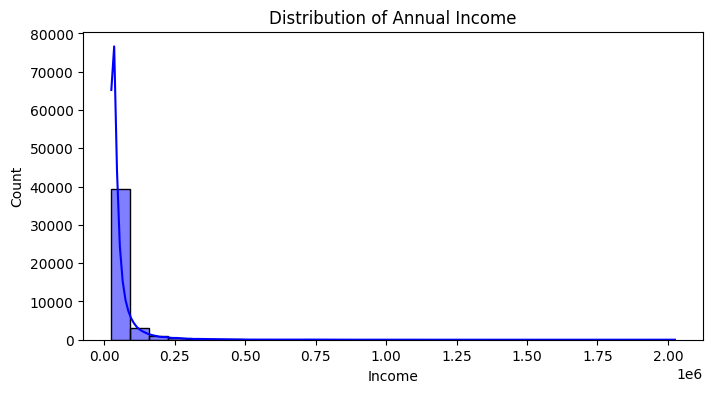

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Annual_Income'], bins=30, kde=True, color='blue')
plt.title('Distribution of Annual Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

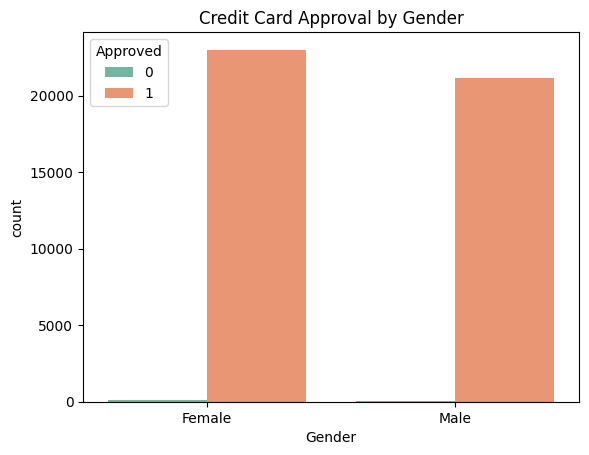

In [21]:
sns.countplot(x='Gender', hue='Approved', data=df, palette='Set2')
plt.title('Credit Card Approval by Gender')
plt.show()

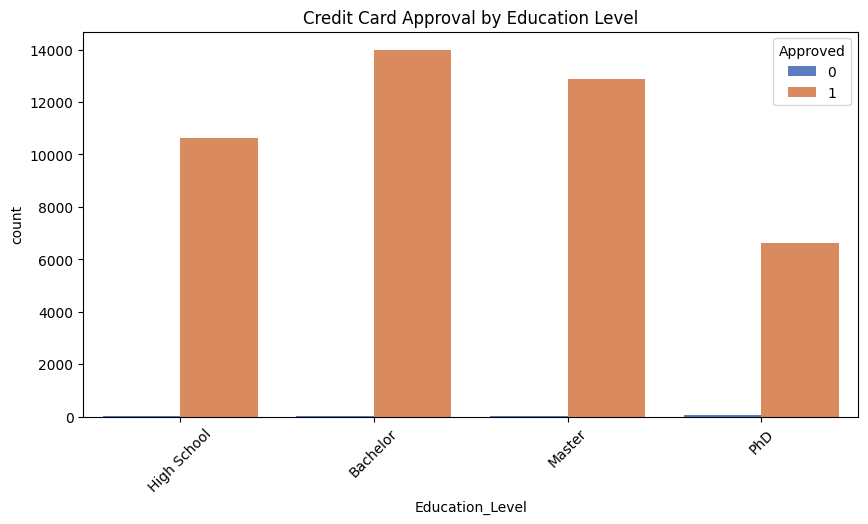

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Education_Level', hue='Approved', data=df, palette='muted')
plt.xticks(rotation=45)
plt.title('Credit Card Approval by Education Level')
plt.show()

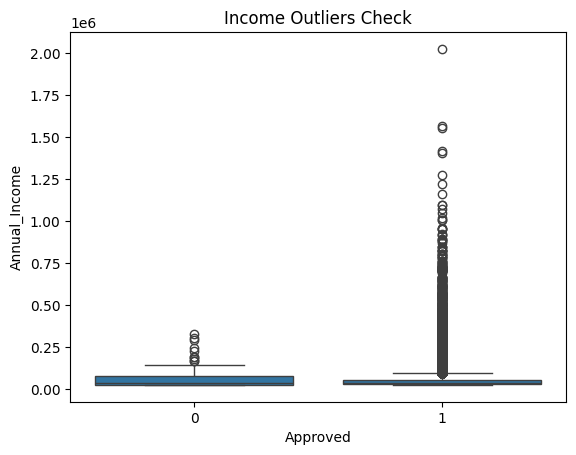

In [23]:
sns.boxplot(x='Approved', y='Annual_Income', data=df)
plt.title('Income Outliers Check')
plt.show()

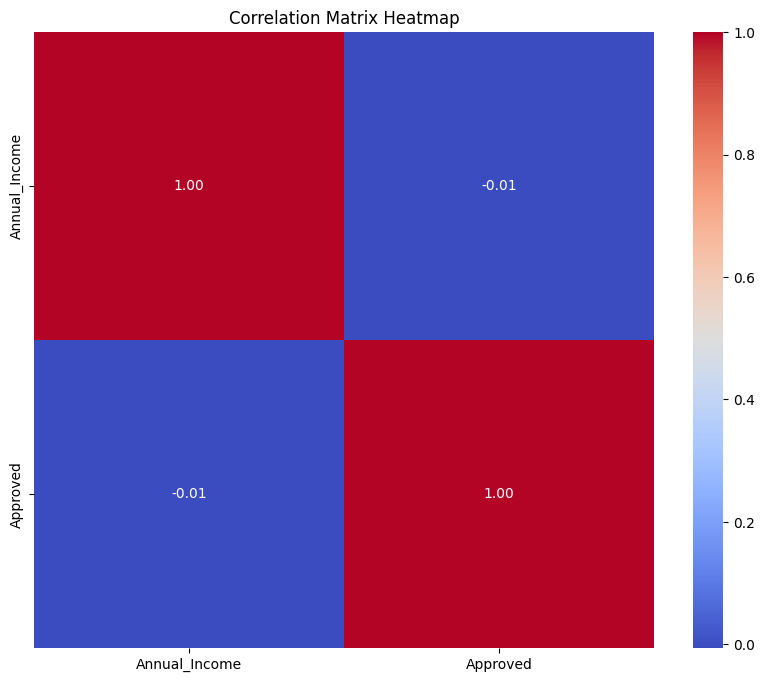

In [24]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [25]:
# Fill missing numeric values with columns median
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
print('Missing values resolved!')

Missing values resolved!


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['Gender', 'Income_Type', 'Education_Level']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print('Encoding complete. Categorical features converted to numbers.')
df.head()

Encoding complete. Categorical features converted to numbers.


,Gender,Annual_Income,Income_Type,Education_Level,Approved
43428,0,97838.0,0,3,0
49906,1,129024.0,1,1,1
29474,1,31200.0,1,0,1
276481,0,25300.0,0,3,1
278846,1,25178.0,0,0,1


In [27]:
X = df.drop(columns=['Approved'])
y = df['Approved']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 35399, Test size: 8850


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Instantiate classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Run training loops
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{name} Test Accuracy: {acc * 100:.2f}%')

Logistic Regression Test Accuracy: 99.85%
Decision Tree Test Accuracy: 99.51%
Random Forest Test Accuracy: 99.68%


c:\Users\alsye\miniforge3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 99.85%


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[   1   12]
 [  16 8821]]

Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.08      0.07        13
           1       1.00      1.00      1.00      8837

    accuracy                           1.00      8850
   macro avg       0.53      0.54      0.53      8850
weighted avg       1.00      1.00      1.00      8850



In [31]:
import joblib
import os

os.makedirs('models', exist_ok=True)
# Export model as a portable file
joblib.dump(best_model, 'models/card_model.joblib')
print('Model file successfully written into models/ folder!')

Model file successfully written into models/ folder!
